# SVM model using HOG 

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn as sk
import skimage
import os

import torch
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm

In [2]:
CIFAR10_ORIG_DIR = "/home/achraf/Research/MLHACK_PAPER/Datasets/cifar-10-original"
PXSIZE=64
PXCELL=8
ORIENTATIONS=6
CELLBLOCK=1
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Loading Data

In [3]:
# Transform pipeline (convert to tensor + normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(PXSIZE),
    # transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Download and load training set
trainset = torchvision.datasets.CIFAR10(
    root='../Datasets/', train=True, download=False, transform=transform
)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Download and load test set
testset = torchvision.datasets.CIFAR10(
    root='../Datasets/', train=False, download=False, transform=transform
)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)


In [ ]:
# images, labels = next(iter(trainloader))
# print(images.shape)
# print(labels[0])
# plt.figure(figsize=(1, 1))
# print(images[0].shape)
# img = np.transpose(images[0], (1,2,0))
# plt.imshow(img)
# plt.title(labels[0])
# plt.show()
# print(np.transpose(images[0], (1,2,0)))

# SVM + HOG 

In [101]:
def hogiffy(images_loader, visualize=False):
    hog_features = []
    labels = []
    for imgs, l in tqdm(images_loader):
        for img in imgs:
            img = np.transpose(img, (1,2,0))
            gray = skimage.color.rgb2gray(img)
            feat = skimage.feature.hog(gray, orientations=ORIENTATIONS, pixels_per_cell=(PXCELL, PXCELL), cells_per_block=(CELLBLOCK, CELLBLOCK), block_norm='L2-Hys', visualize=visualize)
            hog_features.append(feat)
        # print(l)
        labels.extend([i.item() for i in l])
    return np.array(hog_features), np.array(labels)

In [102]:
cifar10_orig_hog, labels = hogiffy(trainloader, visualize=False)
print(cifar10_orig_hog.shape)
# np.save("../Datasets/cifar10-orig-hog", cifar10_orig_hog)
np.savez_compressed("../Datasets/cifar10-orig-hog", Y=labels, X=cifar10_orig_hog)

100%|██████████| 782/782 [00:38<00:00, 20.43it/s]


(50000, 384)


# Visual Test

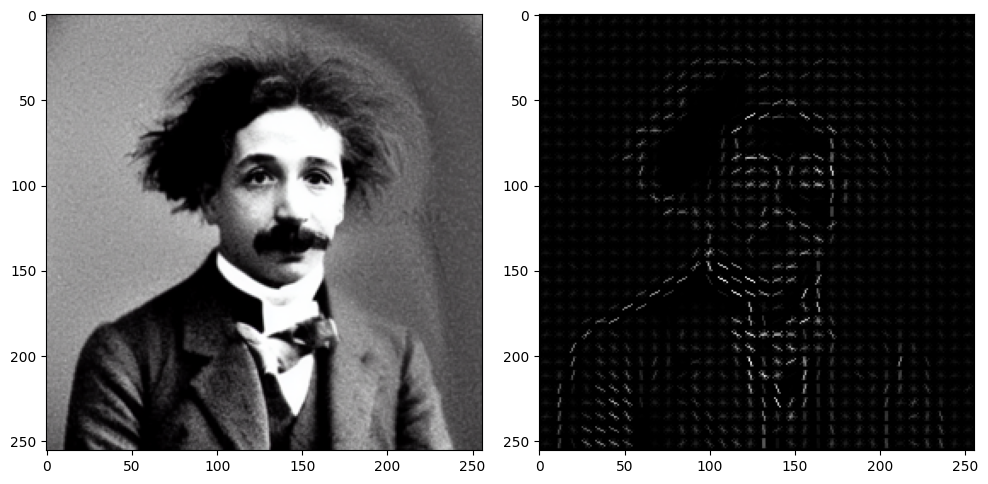

(34596,)


In [9]:
from PIL import  Image

img = Image.open("../Datasets/test_image.jpg").resize((256, 256))
# imgs, _ = next(iter(trainloader))
# img = np.transpose(imgs[17], (1,2,0))
gray = skimage.color.rgb2gray(img)
feat, hog_img = skimage.feature.hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
hog_img = skimage.exposure.rescale_intensity(hog_img, in_range=(0,10))
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(hog_img, cmap="gray")
plt.tight_layout()
plt.show()
print(feat.shape)

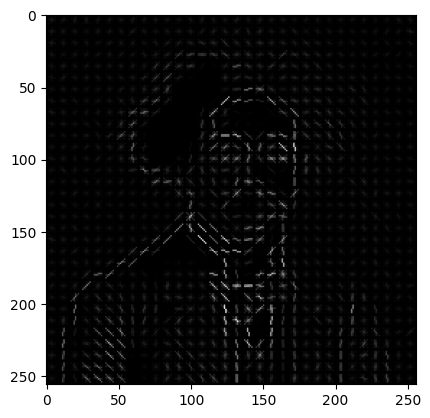

In [4]:
plt.imshow(hog_img, cmap="gray")
plt.show()

# Adversarial Dataset

In [1]:
CIFAR10_ADV_DIR = "/home/achraf/Research/MLHACK_PAPER/Datasets/CIFAR10-FSGM/train"

In [7]:
import numpy as np 
labels = np.load(CIFAR10_ADV_DIR+"/labels.npy")
labels

array([6, 9, 9, ..., 9, 1, 1])

In [2]:
import os
from PIL import Image
import numpy as np

target_size = (64, 64)  # width, height

# 1️⃣ Get all image filenames
image_files = [f for f in os.listdir(CIFAR10_ADV_DIR) if f.endswith((".jpg", ".png", ".jpeg"))]

# 2️⃣ Load all images in a list comprehension
images_np = np.stack([
    np.array(Image.open(os.path.join(CIFAR10_ADV_DIR, f)).convert('RGB'), dtype=np.float32) / 255.0
    for f in image_files
])

print("Images shape:", images_np.shape)  # (num_images, height, width, 3)


Images shape: (50000, 64, 64, 3)


In [4]:
def hogiffy(images, visualize=False):
    hog_features = []
    for img in tqdm(images):
        gray = skimage.color.rgb2gray(img)
        feat = skimage.feature.hog(gray, orientations=ORIENTATIONS, pixels_per_cell=(PXCELL, PXCELL), cells_per_block=(CELLBLOCK, CELLBLOCK), block_norm='L2-Hys', visualize=visualize)
        hog_features.append(feat)
    return np.array(hog_features)

In [ ]:
cifar10_adv_hog = hogiffy(images_np, visualize=False)
print(cifar10_adv_hog.shape)
np.save("../Datasets/cifar10-adv-hog", cifar10_adv_hog)

100%|██████████| 50000/50000 [00:24<00:00, 2041.03it/s]


(50000, 1764)
